In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

OUTPUT_PATH    = '../outputs/'
PROCESSED_PATH = '../data/processed/'

df_ev   = pd.read_csv(PROCESSED_PATH + 'st_evcdp_processed.csv', parse_dates=['timestamp'])
ev_preds = pd.read_csv(OUTPUT_PATH + 'ev_demand_predictions.csv')

print("EV data shape    :", df_ev.shape)
print("Predictions shape:", ev_preds.shape)

EV data shape    : (2134080, 15)
Predictions shape: (98815, 12)


In [ ]:
BASELINE_TARIFF = 15.0   
SURGE_MULTIPLIER    = 1.5    
DISCOUNT_MULTIPLIER = 0.7   

def compute_dynamic_tariff(utilization_rate):
    if utilization_rate > 0.8:
        return BASELINE_TARIFF * SURGE_MULTIPLIER       
    elif utilization_rate < 0.3:
        return BASELINE_TARIFF * DISCOUNT_MULTIPLIER    
    else:
        slope = (BASELINE_TARIFF * SURGE_MULTIPLIER - BASELINE_TARIFF * DISCOUNT_MULTIPLIER) / (0.8 - 0.3)
        return BASELINE_TARIFF * DISCOUNT_MULTIPLIER + slope * (utilization_rate - 0.3)


def apply_tariff(util_series):
    conditions = [
        util_series > 0.8,
        util_series < 0.3
    ]
    choices = [
        BASELINE_TARIFF * SURGE_MULTIPLIER,
        BASELINE_TARIFF * DISCOUNT_MULTIPLIER
    ]
    shoulder_tariff = (
        BASELINE_TARIFF * DISCOUNT_MULTIPLIER +
        ((BASELINE_TARIFF * SURGE_MULTIPLIER - BASELINE_TARIFF * DISCOUNT_MULTIPLIER) / (0.8 - 0.3))
        * (util_series - 0.3)
    )
    return np.select(conditions, choices, default=shoulder_tariff)

test_utils = [0.1, 0.3, 0.5, 0.7, 0.85, 1.0]
print("Tariff schedule:")
print(f"{'Utilization':>12} | {'Tariff (₹/kWh)':>15} | {'Zone':>10}")
print("-" * 45)
for u in test_utils:
    t = compute_dynamic_tariff(u)
    zone = 'SURGE' if u > 0.8 else ('DISCOUNT' if u < 0.3 else 'SHOULDER')
    print(f"{u:>12.2f} | {t:>15.2f} | {zone:>10}")

Tariff schedule:
 Utilization |  Tariff (₹/kWh) |       Zone
---------------------------------------------
        0.10 |           10.50 |   DISCOUNT
        0.30 |           10.50 |   SHOULDER
        0.50 |           15.30 |   SHOULDER
        0.70 |           20.10 |   SHOULDER
        0.85 |           22.50 |      SURGE
        1.00 |           22.50 |      SURGE


In [ ]:
ev_preds['dynamic_tariff']  = apply_tariff(ev_preds['predicted_utilization'])
ev_preds['baseline_tariff'] = BASELINE_TARIFF

ev_preds_full = ev_preds.copy()

ev_preds_full.dropna(subset=['volume'], inplace=True)

ev_preds_full['revenue_dynamic']  = ev_preds_full['dynamic_tariff']  * ev_preds_full['volume']
ev_preds_full['revenue_baseline'] = ev_preds_full['baseline_tariff'] * ev_preds_full['volume']

total_dynamic  = ev_preds_full['revenue_dynamic'].sum()
total_baseline = ev_preds_full['revenue_baseline'].sum()
revenue_gain   = ((total_dynamic - total_baseline) / total_baseline) * 100

print(f"Total Baseline Revenue : {total_baseline:,.0f}")
print(f"Total Dynamic Revenue  : {total_dynamic:,.0f}")
print(f"Revenue Gain %         : {revenue_gain:.2f}%")

Total Baseline Revenue : 54,810,967
Total Dynamic Revenue  : 81,070,266
Revenue Gain %         : 47.91%


Avg Utilization  — Before: 0.771  After: 0.677
Congestion %     — Before: 66.3%  After: 63.0%


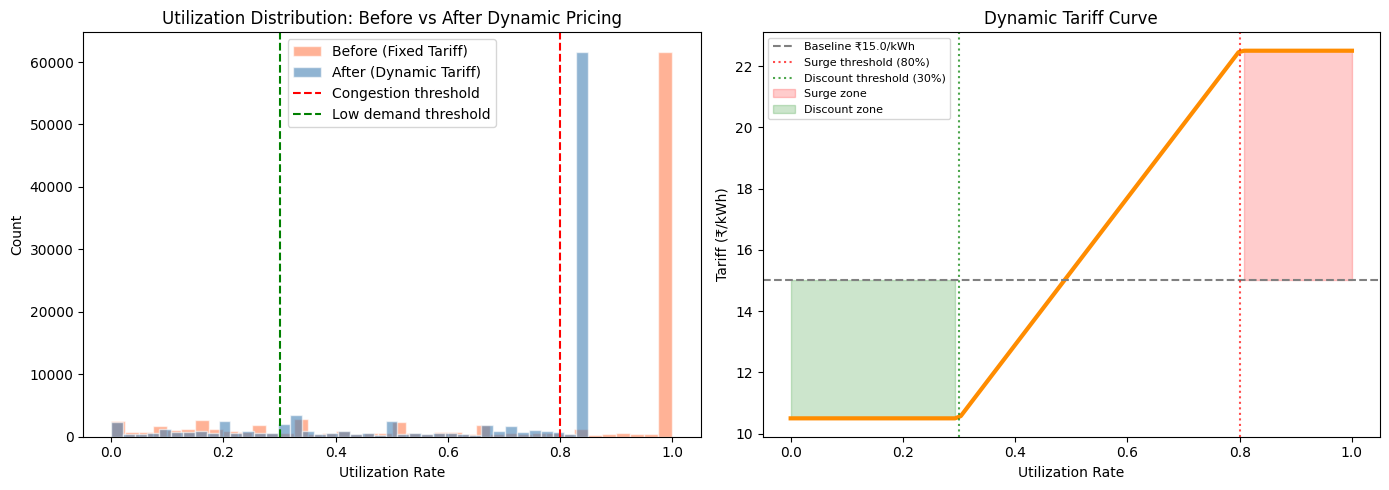

In [ ]:
ev_preds_full['simulated_utilization'] = ev_preds_full['predicted_utilization'].copy()

surge_mask    = ev_preds_full['predicted_utilization'] > 0.8
discount_mask = ev_preds_full['predicted_utilization'] < 0.3

ev_preds_full.loc[surge_mask,    'simulated_utilization'] *= 0.85
ev_preds_full.loc[discount_mask, 'simulated_utilization'] *= 1.20
ev_preds_full['simulated_utilization'] = ev_preds_full['simulated_utilization'].clip(0, 1)

before_util = ev_preds_full['predicted_utilization'].mean()
after_util  = ev_preds_full['simulated_utilization'].mean()
before_cong = (ev_preds_full['predicted_utilization'] > 0.8).mean() * 100
after_cong  = (ev_preds_full['simulated_utilization'] > 0.8).mean() * 100

print(f"Avg Utilization  — Before: {before_util:.3f}  After: {after_util:.3f}")
print(f"Congestion %     — Before: {before_cong:.1f}%  After: {after_cong:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ev_preds_full['predicted_utilization'],  bins=40, alpha=0.6, 
             color='coral',     label='Before (Fixed Tariff)', edgecolor='white')
axes[0].hist(ev_preds_full['simulated_utilization'],  bins=40, alpha=0.6, 
             color='steelblue', label='After (Dynamic Tariff)', edgecolor='white')
axes[0].axvline(0.8, color='red',   linestyle='--', label='Congestion threshold')
axes[0].axvline(0.3, color='green', linestyle='--', label='Low demand threshold')
axes[0].set_title('Utilization Distribution: Before vs After Dynamic Pricing')
axes[0].set_xlabel('Utilization Rate')
axes[0].set_ylabel('Count')
axes[0].legend()

util_range = np.linspace(0, 1, 100)
tariff_range = [compute_dynamic_tariff(u) for u in util_range]

axes[1].plot(util_range, tariff_range, color='darkorange', linewidth=3)
axes[1].axhline(BASELINE_TARIFF, color='gray', linestyle='--', label=f'Baseline ₹{BASELINE_TARIFF}/kWh')
axes[1].axvline(0.8, color='red',   linestyle=':', alpha=0.7, label='Surge threshold (80%)')
axes[1].axvline(0.3, color='green', linestyle=':', alpha=0.7, label='Discount threshold (30%)')
axes[1].fill_between(util_range, tariff_range, BASELINE_TARIFF,
                     where=[u > 0.8 for u in util_range], 
                     alpha=0.2, color='red', label='Surge zone')
axes[1].fill_between(util_range, tariff_range, BASELINE_TARIFF,
                     where=[u < 0.3 for u in util_range], 
                     alpha=0.2, color='green', label='Discount zone')
axes[1].set_title('Dynamic Tariff Curve')
axes[1].set_xlabel('Utilization Rate')
axes[1].set_ylabel('Tariff (₹/kWh)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'tariff_pricing_results.png', bbox_inches='tight')
plt.show()

Off-Peak Records Before : 15,980
Off-Peak Records After  : 13,594
Estimated Sessions Shifted to Off-Peak: 3,196


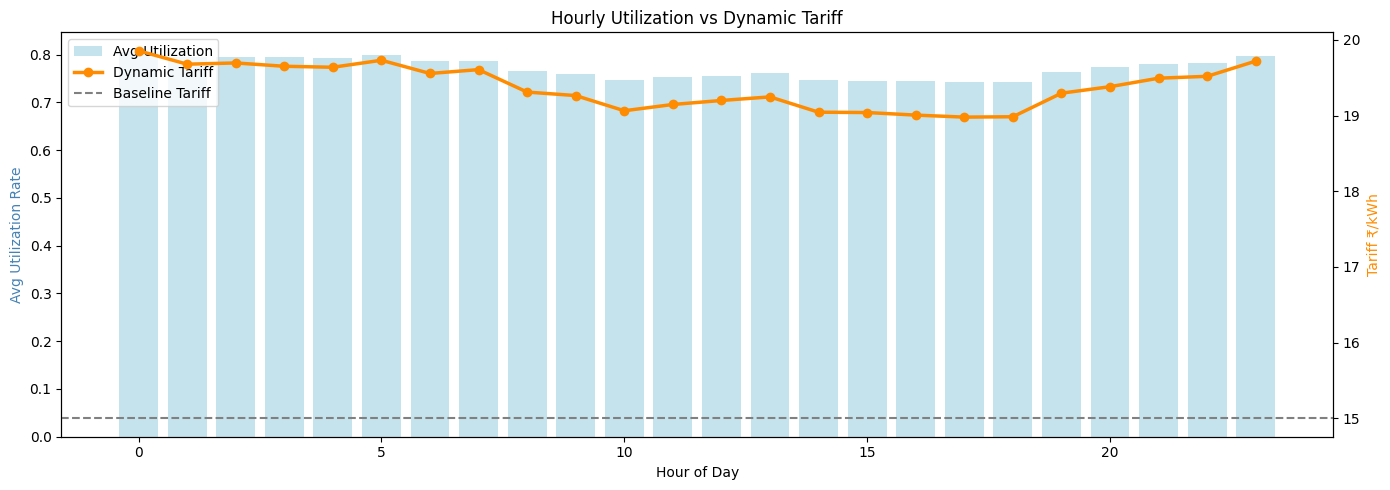

In [ ]:
before_offpeak = (ev_preds_full['predicted_utilization'] < 0.3).sum()
after_offpeak  = (ev_preds_full['simulated_utilization'] < 0.3).sum()

sessions_shifted = int(before_offpeak * 0.20)

print(f"Off-Peak Records Before : {before_offpeak:,}")
print(f"Off-Peak Records After  : {after_offpeak:,}")
print(f"Estimated Sessions Shifted to Off-Peak: {sessions_shifted:,}")

hourly_tariff = ev_preds_full.groupby('hour_of_day').agg(
    avg_util      = ('predicted_utilization', 'mean'),
    avg_tariff    = ('dynamic_tariff', 'mean'),
    baseline      = ('baseline_tariff', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(hourly_tariff['hour_of_day'], hourly_tariff['avg_util'], 
        color='lightblue', alpha=0.7, label='Avg Utilization')
ax2.plot(hourly_tariff['hour_of_day'], hourly_tariff['avg_tariff'], 
         color='darkorange', linewidth=2.5, marker='o', label='Dynamic Tariff')
ax2.axhline(BASELINE_TARIFF, color='gray', linestyle='--', label='Baseline Tariff')

ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Avg Utilization Rate', color='steelblue')
ax2.set_ylabel('Tariff ₹/kWh', color='darkorange')
ax1.set_title('Hourly Utilization vs Dynamic Tariff')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'hourly_tariff_profile.png', bbox_inches='tight')
plt.show()

In [ ]:
tariff_summary = pd.DataFrame({
    'metric': [
        'Baseline Revenue', 'Dynamic Revenue', 'Revenue Gain %',
        'Avg Utilization Before', 'Avg Utilization After',
        'Congestion % Before', 'Congestion % After',
        'Sessions Shifted to Off-Peak'
    ],
    'value': [
        round(total_baseline, 2),
        round(total_dynamic, 2),
        round(revenue_gain, 2),
        round(before_util, 3),
        round(after_util, 3),
        round(before_cong, 1),
        round(after_cong, 1),
        sessions_shifted
    ]
})

tariff_summary.to_csv(OUTPUT_PATH + 'tariff_pricing_summary.csv', index=False)
ev_preds_full[['predicted_utilization','dynamic_tariff',
               'baseline_tariff','revenue_dynamic','revenue_baseline',
               'simulated_utilization']].to_csv(OUTPUT_PATH + 'tariff_decisions.csv', index=False)

print("Saved: tariff_pricing_summary.csv")
print("Saved: tariff_decisions.csv")
print("\nTariff Summary:")
print(tariff_summary.to_string(index=False))

Saved: tariff_pricing_summary.csv
Saved: tariff_decisions.csv

Tariff Summary:
                      metric        value
            Baseline Revenue 54810967.320
             Dynamic Revenue 81070265.900
              Revenue Gain %       47.910
      Avg Utilization Before        0.771
       Avg Utilization After        0.677
         Congestion % Before       66.300
          Congestion % After       63.000
Sessions Shifted to Off-Peak     3196.000

Notebook 4 done! Ready for Monitoring Agent.
